# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

GENESET="004"
DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
DESEQ2_NAME = "baseline_deseq2"
EDGER_NAME = "baseline_edgeR"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# EdgeR Desseq hyperparaters

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
# Filter varibales for pseudobulk cells
MIN_CELLS_PER_PSUDOCELL=10
MIN_COUNTS_PER_PSEUDOCELL=1000
MIN_PSEUDOCELL_PER_GROUP=2
# Filter gens noisy/low expressed
MIN_COUNTS=10
LARGE_N=10
MIN_TOTAL_COUNTS=15
MIN_PROP_BY_EXPR=0.5
MIN_PROP_BY_PROP=0.1
MIN_SMPLS=2
#columns names
P_VAL_COL_NAME = f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
ADJ_P_VAL_COL_NAME = f"adj_{P_VAL_COL_NAME}"
LOGFC_COL_NAME = f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL_NAME = "gene"
N_TOP_GENES_TO_NAME = 10
# thr for gene signifcat
LOGFC_THR=0.1

FULL_MODEL = "~ " + " + ".join([CONTRAST_VARIABLE, *COVARIATES_FOR_DEG])
print(FULL_MODEL)

~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic


# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).

In [2]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    # 2 differt saving folders
    results_folder_deseq2 = os.path.join(DATASET_FOLDER, dataset, DESEQ2_NAME)
    os.makedirs(results_folder_deseq2, exist_ok=True)
    results_folder_edgeR = os.path.join(DATASET_FOLDER, dataset, EDGER_NAME)
    os.makedirs(results_folder_edgeR, exist_ok=True)

    # same  initial adata
    # dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}_pseudobulked.h5ad")
    # cov_df_csv_path = os.path.join(results_folder_deseq2, "covariates_df.csv") # ny defult save in desseq

    ###################

    # Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)


    ##################

    # Update obs of .qs obj
    # add_metadata_to_qs(
    #     base_qs_path=dataset_path_qs,
    #     new_metadata_df=pd.read_csv(cov_df_csv_path),
    #     barcode_col="barcode",
    # )

    #break


######
 Processing dataset: depleted_0.00_dorsal_matrix 
######


######
 Processing dataset: depleted_0.10_dorsal_matrix 
######


######
 Processing dataset: depleted_0.20_dorsal_matrix 
######


######
 Processing dataset: depleted_0.30_dorsal_matrix 
######


######
 Processing dataset: depleted_0.40_dorsal_matrix 
######


######
 Processing dataset: depleted_0.50_dorsal_matrix 
######


######
 Processing dataset: depleted_0.60_dorsal_matrix 
######


######
 Processing dataset: depleted_0.70_dorsal_matrix 
######


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######



# Psudobulk DEG

In [3]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    # 2 differt saving folders
    results_folder_deseq2 = os.path.join(DATASET_FOLDER, dataset, DESEQ2_NAME)
    save_csv_path_deseq2 = os.path.join(results_folder_deseq2, f"{dataset}-{DESEQ2_NAME}_results.csv")
    results_folder_edgeR = os.path.join(DATASET_FOLDER, dataset, EDGER_NAME)
    save_csv_path_edgeR = os.path.join(results_folder_edgeR, f"{dataset}-{EDGER_NAME}_results.csv")

    # same  initial adata
    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}_pseudobulked.h5ad")
    results_folder =results_folder_deseq2 # ny defult save in desseq


    # Read file
    adata_psuedo = sc.read_h5ad(dataset_path_h5ad)

    # Check for collinearity
    #DEG.check_corr_cov_in_design(adata_psuedo, FULL_MODEL, corr_thr=0.7, split=" + ")

    # Run psuedobulk
    try:
        original_show = plt.show

        df_merged, res_df_edgeR, res_df_pds2 = DEG.DEG_deseq2_edgeR(
            adata_pb_all=adata_psuedo,
            psuedobulk_group_for_deg=None, # do not subset
            psuedobulk_group_for_deg_col=None, # do not subset
            design_formula=FULL_MODEL,
            save_folder=results_folder,
            SAMPLE_VARIABLE=SAMPLE_VARIABLE,
            CONTRAST_VARIABLE=CONTRAST_VARIABLE,
            MIN_CELLS_PER_PSUDOCELL=MIN_CELLS_PER_PSUDOCELL,
            MIN_COUNTS_PER_PSEUDOCELL=MIN_COUNTS_PER_PSEUDOCELL,
            MIN_PSEUDOCELL_PER_GROUP=MIN_PSEUDOCELL_PER_GROUP,
            MIN_COUNTS=MIN_COUNTS,
            LARGE_N=LARGE_N,
            MIN_TOTAL_COUNTS=MIN_TOTAL_COUNTS,
            MIN_PROP_BY_EXPR=MIN_PROP_BY_EXPR,
            MIN_PROP_BY_PROP=MIN_PROP_BY_PROP,
            MIN_SMPLS=MIN_SMPLS,
            CONTRAST_BASELINE=CONTRAST_BASELINE,
            CONTRAST_STIM=CONTRAST_STIM,
            ALPHA_MULTIPLE_TEST=ALPHA_MULTIPLE_TEST,
            LOGFC_THR=LOGFC_THR,
            PVAL_THR=PVAL_THR,
            N_TOP_GENES_TO_NAME=N_TOP_GENES_TO_NAME,
            GENE_COL_NAME=GENE_COL_NAME,
            LOGFC_COL_NAME=LOGFC_COL_NAME,
            ADJ_P_VAL_COL_NAME=ADJ_P_VAL_COL_NAME,
            P_VAL_COL_NAME=P_VAL_COL_NAME, # Rename p.val col
            calculate_umap=False
        )

        res_df_edgeR.to_csv(save_csv_path_edgeR, index=False)
        res_df_pds2.to_csv(save_csv_path_deseq2, index=False)


    finally:
        plt.show = original_show

    #break

    


######
 Processing dataset: depleted_0.00_dorsal_matrix 
######


            #########################
            ### Processing psudobulk group: None
            #########################
            

Corrected dsign Matrix: ~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic
Samples per group: {'case': np.int64(10), 'control': np.int64(9)}

Design formula: ~ case_control + Age.at.Death + Sex + PMI + pct_mt + pct_intronic



/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "pct_ribosomal". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Neighborhood_bootstrapping_probability". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
2026-02-10 13:58:36 | [WARNING] R callback write-console: In addition:   
2026-02-10 13:58:36 | [WARNING] R callback write-console: Warning messages:
  
2026-02-10 13:58:36 | [WARNING] R callback write-console: 1:   
2026-02-10 13:58:36 | [WARNING] R callback write

Using None as control genes, passed at DeseqDataSet initialization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:378: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:230: RuntimeWarning: invalid value encountered in subtract
  -logbinom
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:382: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:385: RuntimeWarning: invalid value encountered in divide
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:378: RuntimeWarning: overflow encountered in exp
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.p

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  0.  0.  0.]
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG       1345.032882       -0.156152  0.096900 -1.611481  0.107075  0.999551
A1BG-AS1   4047.644825       -0.074009  0.105665 -0.700410  0.483671  0.999551
A2M         436.748052        0.465087  0.303480  1.532512  0.125396  0.999551
A2M-AS1     706.401312        0.069652  0.153576  0.453533  0.650165  0.999551
A2ML1       531.991986       -0.084784  0.158014 -0.536561  0.591571  0.999551
...                ...             ...       ...       ...       ...       ...
ZXDC      21818.848639       -0.026161  0.083710 -0.312518  0.754647  0.999551
ZYG11B    16860.630069        0.018833  0.062684  0.300443  0.763839  0.999551
ZYX        3772.255909        0.013922  0.132809  0.104829  0.916512  0.999551
ZZEF1     26549.565671       -0.046701  0.055098 -0.847597  0.396663  0.999551
ZZZ3      47769.792835        0.174684  0.0761

...

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  0.  0.  0.]
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        788.899925        0.046031  0.109873  0.418943  0.675258  0.883702
A1BG-AS1   2166.468391       -0.113413  0.122393 -0.926634  0.354116  0.706012
A2M         269.778372        0.857048  0.349002  2.455714  0.014061  0.140605
A2M-AS1     391.293505        0.265589  0.175260  1.515399  0.129672  0.455021
A2ML1       284.589950       -0.282953  0.175632 -1.611053  0.107168  0.419615
...                ...             ...       ...       ...       ...       ...
ZXDC      11597.464070       -0.021468  0.098997 -0.216852  0.828323  0.945088
ZYG11B     9237.382234        0.008642  0.081992  0.105399  0.916059  0.974980
ZYX        2178.297858        0.124301  0.166651  0.745874  0.455743  0.777535
ZZEF1     14059.896579       -0.057836  0.071668 -0.806993  0.419670  0.755311
ZZZ3      25937.338311        0.287732  0.0922

/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "pct_ribosomal". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "Neighborhood_bootstrapping_probability". Fall back to string conversion. The error is: Converting pandas "Category" series to R factor is only possible when categories are strings.
  warnings.warn('Error while trying to convert '
2026-02-10 14:02:39 | [WARNING] R callback write-console: In addition:   
2026-02-10 14:02:39 | [WARNING] R callback write-console: Warning messages:
  
2026-02-10 14:02:39 | [WARNING] R callback write-console: 1:   
2026-02-10 14:02:39 | [WARNING] R callback write

Using None as control genes, passed at DeseqDataSet initialization


/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:385: RuntimeWarning: overflow encountered in multiply
  + ((1 / disp + counts) * mu_ / (1 / disp + mu_)) @ X
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:232: RuntimeWarning: invalid value encountered in multiply
  - counts * np.log(mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:378: RuntimeWarning: overflow encountered in multiply
  mu_ = np.maximum(size_factors * np.exp(X @ beta), min_mu)
/home/gdallagl/myworkdir/XDP/.venv/lib/python3.11/site-packages/pydeseq2/utils.py:382: RuntimeWarning: overflow encoun

Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.  0.  0.  0.  0.  0.]
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG        640.584077        0.071948  0.115385  0.623548  0.532925  0.795280
A1BG-AS1   1735.894195       -0.135610  0.125160 -1.083489  0.278591  0.604647
A2M         220.802761        0.908719  0.346979  2.618945  0.008820  0.084869
A2M-AS1     311.111747        0.294468  0.183961  1.600705  0.109442  0.377537
A2ML1       228.088547       -0.286684  0.184815 -1.551190  0.120856  0.397721
...                ...             ...       ...       ...       ...       ...
ZXDC       9283.721885       -0.013507  0.103881 -0.130026  0.896546  0.967103
ZYG11B     7499.771038        0.019578  0.088934  0.220145  0.825759  0.941650
ZYX        1797.389494        0.216859  0.179775  1.206281  0.227709  0.547222
ZZEF1     11263.692595       -0.048863  0.078472 -0.622676  0.533497  0.795501
ZZZ3      20697.487034        0.287152  0.0956

In [4]:
res_df_pds2

,gene,baseMean,logFC_case_controlcase,lfcSE,stat,p_case_controlcase,adj_p_case_controlcase,contrast,method,is_significant
44,TESPA1,8241.764021,-5.845624,0.935410,-6.249265,4.123889e-10,1.574867e-07,None,Deseq2,True
61,ENSG00000286780,9836.213458,-5.238348,0.890846,-5.880196,4.097818e-09,1.135823e-06,None,Deseq2,True
3678,ENSG00000242790,116.662745,-5.237981,2.758210,-1.899051,5.755776e-02,2.687869e-01,None,Deseq2,False
46,ENSG00000287923,11886.558909,-5.054162,0.809884,-6.240600,4.358946e-10,1.584334e-07,None,Deseq2,True
1750,LINC01487,468.260295,-4.498290,1.707027,-2.635161,8.409740e-03,8.250082e-02,None,Deseq2,False
...,...,...,...,...,...,...,...,...,...,...
1069,NPY,115.904372,3.189183,1.022112,3.120189,1.807353e-03,2.902744e-02,None,Deseq2,True
166,TOX,357.746036,3.239626,0.666455,4.860980,1.168063e-06,1.201986e-04,None,Deseq2,True
318,WLS,5680.576573,3.762737,0.885097,4.251213,2.126158e-05,1.143401e-03,None,Deseq2,True
15203,ENSG00000285578,172.666485,4.193765,20.187049,0.207745,8.354278e-01,9.441589e-01,None,Deseq2,False


# Plot Results

In [5]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



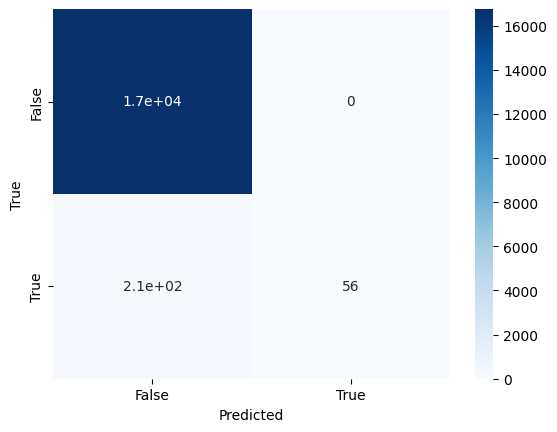

Precision: 1.000
Recall:    0.207
F1 Score:  0.344
Accuracy:  0.987
Clipping 13 genes with -log10(p) > 10


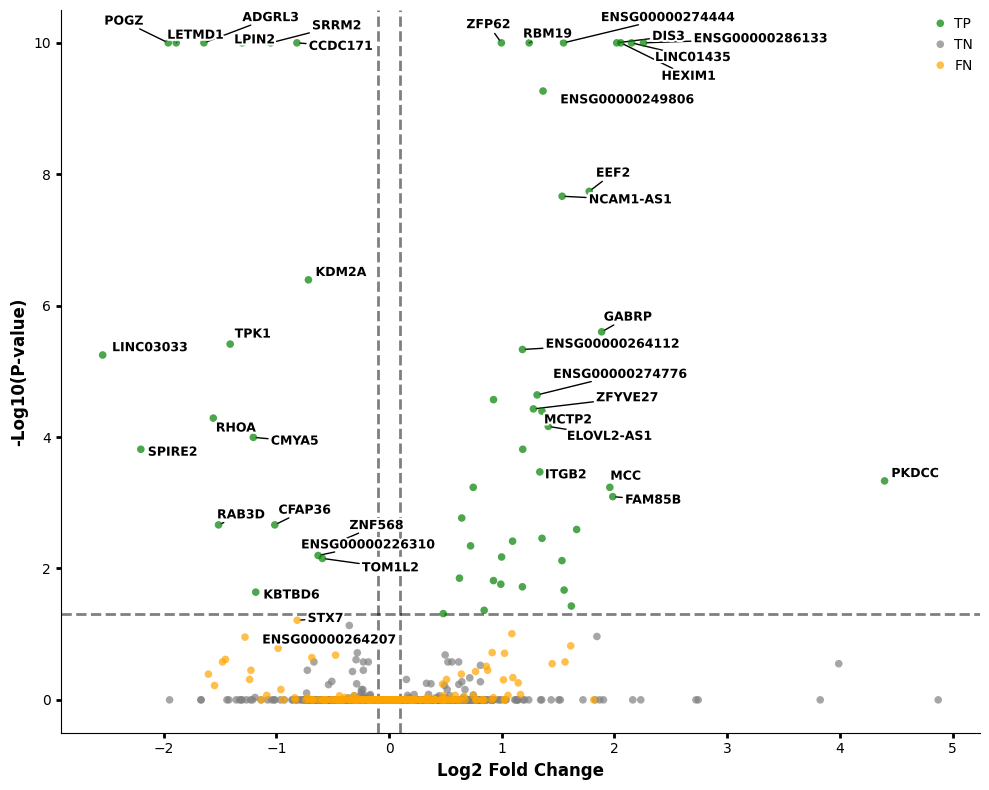

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,LINC03033,-2.539983,6.952166e-09,5.636882e-06,True,True,5.248961,TP,-13.332270
1,SPIRE2,-2.201442,2.703305e-07,1.534306e-04,True,True,3.814088,TP,-8.396495
2,POGZ,-1.958426,7.942751e-165,6.762061e-161,True,True,10.000000,TP,-19.584256
3,CFAP95,-1.946532,8.383851e-02,9.994596e-01,False,False,0.000235,TN,-0.000457
4,LETMD1,-1.887973,2.667753e-202,4.542384e-198,True,True,10.000000,TP,-18.879730
...,...,...,...,...,...,...,...,...,...
17022,ENSG00000276256,2.742878,3.523918e-02,9.994596e-01,False,False,0.000235,TN,0.000644
17023,HCG24,3.824784,2.520554e-02,9.994596e-01,False,False,0.000235,TN,0.000898
17024,ENSG00000236209,3.989158,1.351051e-03,2.817395e-01,False,False,0.550152,TN,2.194645
17025,PKDCC,4.395666,8.732120e-07,4.646307e-04,True,True,3.332892,TP,14.650281


In [6]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, DESEQ2_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{DESEQ2_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break